Generate some test data with error added in manually 

**Reaction sequence**  
1. $\mathrm{H^+} + e^- + {*} \;\rightleftharpoons\; \mathrm{H}^*$

2. $ \mathrm{H}^* + \mathrm{H^+} + e^- \;\longrightarrow\; \mathrm{H}_2 + {*} $    (RDS)

beta is always considered 0.5 <br>
Doing some math with the chosen model: <br>
alpha = 1.5 - theta_H <br>
delta = 2 - theta_H

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

# Constants (SI Units)
R  = 8.31446261815324
T  = 298.15
F  = 96485.33212
kb = 1.380649e-23
h  = 6.62607015e-34

# Model parameters
E1_0 = 0 # Reference value
E2_0 = 0 # Reference value
beta = 0.5 # Parameter 1
deltaG1_0 = -10e3 # Parameter 2 - about 0.1 eV
Gact2_0 = 100e3 + 0.5 * deltaG1_0 # Assume BEP relationship  
noise_fraction = 0.03 # Error parameter 1
area = 10

# Experimental parameters 
PROTON_CONC_LIST = np.array([1e-3, 1e-2, 1e-1, 1e-0])
E = np.arange(-1, 0, 0.01) 

# Data generation 
deltaG1 = deltaG1_0 + F*(E-E1_0)
K1 = np.exp(-deltaG1/(R*T))

Gact2 = Gact2_0 + beta*F*(E-E2_0)
k2 = (kb*T/h)*np.exp(-Gact2/(R*T))

rate = np.zeros((len(E), len(PROTON_CONC_LIST)))
for i, conc_proton in enumerate(PROTON_CONC_LIST):
    rate[:,i] = area*K1*k2*conc_proton**2/(1+K1*conc_proton)

# Add error
rate = rate + np.random.normal(loc = 0.0, scale = noise_fraction * np.abs(rate), size = rate.shape)

log_rate = np.log(rate)
log_conc = np.log(PROTON_CONC_LIST)
alpha = -(R*T/F)*np.gradient(log_rate, E, axis=0)

d_lnc = np.diff(np.log(PROTON_CONC_LIST))
d_log_rate = np.diff(log_rate, axis=1)
delta = d_log_rate/d_lnc

# Export data 
np.savez("fake_data3.npz", E = E, delta = delta, alpha = alpha)

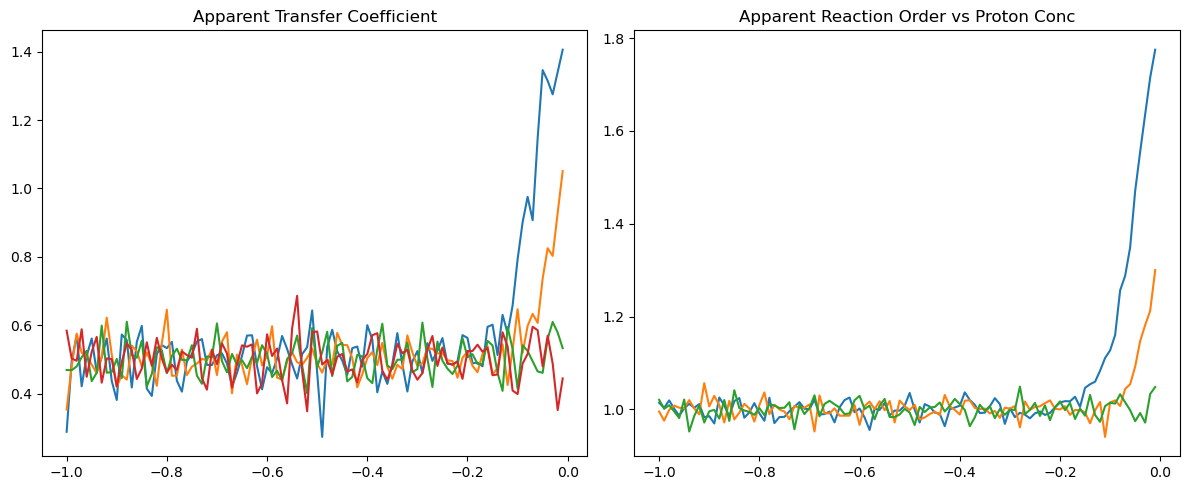

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(E, alpha)
axes[0].set_title("Apparent Transfer Coefficient")
axes[1].plot(E, delta)
axes[1].set_title("Apparent Reaction Order vs Proton Conc")
plt.tight_layout()
plt.show()

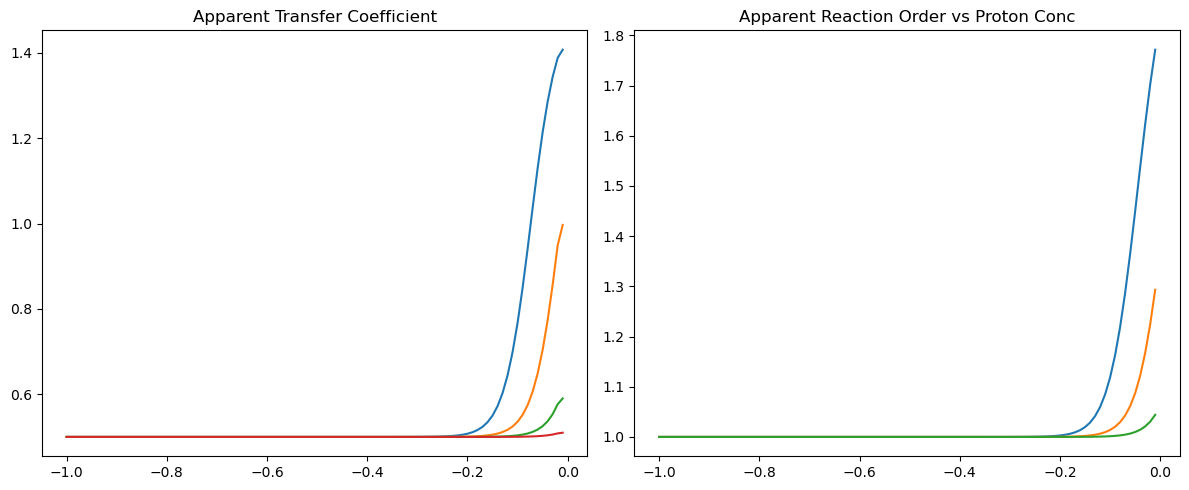

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(E, alpha)
axes[0].set_title("Apparent Transfer Coefficient")
axes[1].plot(E, delta)
axes[1].set_title("Apparent Reaction Order vs Proton Conc")
plt.tight_layout()
plt.show()